# Elliptic Curves Pseudo Random Number Generators

# Dependencies

In [89]:
from math import erfc, sqrt
from numpy import set_printoptions
from scipy.special import gammaincc
from tabulate import tabulate
import random
import matplotlib.pyplot as plt

set_printoptions(precision=4)

## Setting a timer

In [11]:
import time
t_0 = time.time()

### Tu código aquí

t_1 = time.time()
total = t_1 - t_0
print(total)

0.0


# Initial Functions

In [13]:
# Finds the m- ary expansion of n
def getExpansion (n ,m):
    listOfDigits =[]
    while n >= m:
        digit =n%m
        listOfDigits . append ( digit )
        n =(n - digit ) // m
    listOfDigits.append(n)
    return listOfDigits
    
def intToText (n):
    t= getExpansion(n ,256)
    myString =''
    for i in t :
        myString = myString + chr(i)
    return myString

def textToInt (s):
    n =0
    k =0
    for i in s :
        n=n +ord( i) *(256** k)
        k=k +1
    return n

# Output the multiplicative inverse of a modulo p
def multInverse (a , p):
    result = extendedGCD (a , p)
    if result [0]!=1: # Error message if a and p are not relatively prime
        s=" Numbers needs to be relatively prime "
        return s
    inv = result [1]% p
    return inv

#extended euclidean algorithm
# Output [r,s,t] satisfying s*a+t*b=r=gcd(a,b)
def extendedGCD(a , b):
    r0 , r=a ,b
    s0 , s =1 ,0
    t0 , t =0 ,1
    while (r >0):
        tempr , temps , tempt =r ,s ,t
        q= r0 // r
        r ,s , t=r0 - q*r ,s0 -q*s ,t0 - q*t
        r0 , s0 , t0 = tempr , temps , tempt
    return [r0 ,s0 , t0 ]

def fast2Power (a ,n ,m):
    res = 1
    while n > 0:
        if n % 2 == 1: #If the bit is 1 multiply by the corresponding square
            res = ( res * a ) % m
        a =( a * a) % m
        n = n // 2
    return res

In [14]:
def findSquareRoot (N ,p) :
    N0 = N % p
    if fast2Power (N0, (p - 1) // 2 ,p) == 1: #Euler ’s criterion
        if p % 4 == 3:
            x1 = fast2Power (N0, (p + 1) // 4 , p) #see assignment 2 exercise 2 theoretical part
            y1 = p - x1
            return [x1 , y1]
        else :
            for i in range(1 , (( p - 1) // 2) + 1):
                if (i * i) % p == N0:
                    x1 = i
                    y1 = p - i
                    return [x1 , y1]
    return []
    
def generateCurve (E , p):
    if isElliptic (E , p) == False :
        print (" This is not an elliptic curve ")
        return None
    A, B = E
    listOfPointsLinear =["O"]
    for x in range (p):
        a =(x**3 + A*x + B) % p
        if a == 0:
            listOfPointsLinear.append ([x ,0])
        if fast2Power (a, (p - 1) // 2, p) == 1: # Euler ’s criterion there are solutions
            y1, y2 = findSquareRoot(a, p)
            listOfPointsLinear.append([x, y1])
            listOfPointsLinear.append([x, y2])
    return listOfPointsLinear

def isElliptic (E, p):
    A, B = E
    discr = (4*( A **3) +27*( B **2) )%p
    return discr != 0

def pointOnCurve (P ,E ,p) :
    if P == "O":
        return True
    else :
        A, B = E
        x, y = P
        return (y **2) %p ==( x **3+ A* x+B) %p

def addPoints(P,Q,E,N):
    A = E[0]
    B = E[1]
    if P == "O":
        return Q
    elif Q == "O":
        return P
    x1, x2 = P[0], Q[0]
    y1, y2 = P[1], Q[1]
    if x1 == x2 % N and y1 == -y2 % N:
        return "O"
    else:
        if P != Q:
            d1 = extendedGCD(x2 - x1, N)[0]
            if d1 != 1:
                return [-1, d1]
            lmbda = (y2 - y1) * multInverse(x2 - x1, N) % N
        else:
            d2 = extendedGCD(2 * y1, N)[0]
            if d2 != 1:
                return [-1, d2]
            lmbda = (3 * fast2Power(x1, 2, N) + A) * multInverse(2 * y1, N) % N
        x3 = (fast2Power(lmbda, 2, N) - x1 - x2) % N
        y3 = (lmbda * (x1 - x3) - y1) % N
        return [x3, y3]
        
def doubleAndAdd(P, n, E, p):
    res = "O"
    while n > 0:
        if n % 2 == 1:
            res = addPoints(res, P, E, p)
        P = addPoints(P, P, E, p)
        n = n // 2
    return res  

# Bitcoin Curve PSRN

In [16]:
def linearGenerator(E, p, G, U):
    """
    :(E,p: elliptic curve,
    :G: a point on the elliptic curve,
    :U: the seed of the generator
    :return: Q = nG + U
    """
    P = []
    for i in range(p):
        Q = addPoints(doubleAndAdd(G, i, E, p), U, E, p) # P = iG + U
        if Q in P:
            break
        P.append(Q)
    return P

def lastKbits(n, k):
    """
    returns the last k bits of a given number n. 
    If its binary representation doesn't have enough bits,
    it will fill to the left with zeroes.
    """
    nb = bin(n)[2:]
    if len(nb) < k:
        return nb.zfill(k)
    else:
        return nb[-k:]

def pointToLastBits(G, k):
    """
    Takes the k last bits from G's binary representation
    """
    if G == 'O':
        return [0]
    Gx, Gy = lastKbits(G[0], k), lastKbits(G[1], k)
    GxList, GyList = [int(k) for k in Gx], [int(k) for k in Gy]
    return [GxList, GyList]

def pointToBitMod(G):
    """
    Add up G both coordinates and take them modulo 2.
    """
    if G == 'O':
        return 0
    return (G[0] + G[1]) % 2

def pointToBit(Points):
    """
    Generates a bit sequence from a given Point sequence
    """
    return [pointToBitMod(Q) for Q in Points]

In [17]:
E = [0,7] #represents the elliptic curve y^2 = x^3 + 7
p = 31 #the true value is bigger
G = [11, 25] #a point on the elliptic curve
L = generateCurve(E, p)

In [18]:
U =  L[8] #another point on the curve, representng the seed
PointsLinear = linearGenerator(E, p, G, U)
print(PointsLinear)

[[5, 15], [4, 28], [1, 15], [20, 28], [7, 28], [0, 21], [25, 15]]


In [19]:
print(pointToLastBits("O", 3))
print(pointToLastBits([20, 28], 1))
print(pointToBitMod([20, 28]))

[0]
[[0], [0]]
0


In [20]:
Gen1 = [pointToLastBits(Q, 1) for Q in PointsLinear]
print(Gen1)

sums = [i[0] + i[1] for i in PointsLinear]
print(sums)

Gen2 = pointToBit(PointsLinear)
print(Gen2)

[[[1], [1]], [[0], [0]], [[1], [1]], [[0], [0]], [[1], [0]], [[0], [1]], [[1], [1]]]
[20, 32, 16, 48, 35, 21, 40]
[0, 0, 0, 0, 1, 1, 0]


In [21]:
nested = [i[0] + i[1] for i in Gen1]
flat = [item for sublist in nested for item in sublist]
print(flat)  # Output: [1, 2, 3, 4, 5, 6]

[1, 1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1]


# Frequency test

In [23]:
def countOnesList(L):
    """
    Count the number of extra ones of a given list of bits.
    
    :param L: a list of 1s and 0s.
    :return: the number of extra 1s compared to 0s (negative values admitted).
            countOnes([0,1,0,1]) = 0 (no extra ones)
            countOnes([0,1,1,1]) = 2 (two extra ones)
            countOnes([0,1,0,0]) = -2 (two extra zeros)
    """
    Ones = [2*i - 1 for i in L]
    return sum(Ones)

def frequencyTest(L, n):
    """
    Evaluates the proportion of 1s with respect to 0s.

    :param L: a list of 1s and 0s
    :return: a p-value
    """
    extraOnes = countOnesList(L)
    stat = abs(extraOnes) / sqrt(n)
    z = stat/sqrt(2)
    pvalue = erfc(z)
    return pvalue

In [24]:
s = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(k) for k in s]
n = 100
alpha = 0.01
frequencyTest(L, 100)

0.10959858339911599

# Frequency test M-Blocks

In [26]:
def partList(L, M, n):
    """
    Partitions list L in blocks of size M
    """
    N = n // M
    R = [L[i*M:(i+1)*M] for i in range(N)]
    return R

def frequencyBlockTest(L, M, n):
    """
    Tests the distribution of ones of a given bit sequence L within each M-block.

    :param L: a list of ones and zeros,
    :param M: the size of each block
    
    :return: pvalue
    """
    N = n // M
    Blocks = partList(L, M, n)
    Ones = [b.count(1)/M for b in Blocks] #contains the proportion of ones within each block
    Terms = [(k - 1/2)**2 for k in Ones]
    chiSquared = 4 * M * sum(Terms)
    pvalue = gammaincc(N/2, chiSquared/2)
    return pvalue

In [27]:
bits = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(b) for b in bits]
n = len(L)
M = 10
frequencyBlockTest(L, M, n)

0.7064384496412808

# Runs test

In [29]:
def onesProportion(L, n):
    """
    Returns the proportion of 1s in a given list L of lenth n.
    """
    return L.count(1)/n

def freqOnesTest(L, n, t = 0.5):
    """
    returns True if the proportion of ones in a list L of length n is close to t (whose default is set to 0.5;
    False otherwise.
    """
    ones = onesProportion(L, n)
    return abs(ones - 1/2) < t

def countRuns(L):
    """
    Counts the number of runs within a list of zeros and ones.
    """
    c = 1
    for k in range(len(L) - 1):
        if L[k] != L[k + 1]:
            c += 1
    return c

def obStatistic(L, n):
    """
    Computes a statistic for the observable L.
    """
    p = onesProportion(L, n)
    v = countRuns(L)
    return abs(v - 2*n*p*(1-p)) / (2*sqrt(2*n)*p*(1-p))

def runsTest(L, n):
    """
    calculates a p-value for runs of L.
    """
    freqTest = freqOnesTest(L, n)
    if not freqTest:
        pvalue = 0
    else:
        statistic = obStatistic(L, n)
        pvalue = erfc(statistic)
    return pvalue

In [30]:
bits = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(b) for b in bits]
n = len(L)
t = 0.2
sig = 0.01

In [31]:
runsTest(L, n)

0.5007979178870902

# Tabulate Results

In [33]:
def testResults(L, n):
    """
    Given a List it performs all former tests and returns for each test its pvalue.
    """
    M = 10
    Tests = ["Frequency test", "Frequency block test", "Runs"]
    freqPv = frequencyTest(L, n)
    freqBlockPv = frequencyBlockTest(L, M, n)
    runsPv = runsTest(L, n)
    Results = [freqPv, freqBlockPv, runsPv]
    Headers = ["Test", "p-value"]
    Values = [[Tests[i], Results[i]] for i in range(len(Tests))]
    print(tabulate(Values, headers=Headers, tablefmt="grid"))

In [34]:
bits = '1100100100001111110110101010001000100001011010001100001000110100110001001100011001100010100010111000'
L = [int(b) for b in bits]
n = len(L)
print(L)

[1, 1, 0, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 0, 1, 1, 1, 0, 0, 0]


In [35]:
testResults(L, n)

+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       |  0.109599 |
+----------------------+-----------+
| Frequency block test |  0.706438 |
+----------------------+-----------+
| Runs                 |  0.500798 |
+----------------------+-----------+


# Model Testing

In [37]:
def generateLinSeq(E, p, i, s):
    """
    Generates a bit sequence using the linear generator model for the elliptic curve (E, p)
    with initial point G and seed U.
    """
    L = generateCurve(E, p)
    print("Model size:", len(L))
    points = linearGenerator(E, p, L[i], L[s])
    return pointToBit(points)

def testElliptic(E, p, i, s):
    """
    tests the randomicity of a sequence of bits for the curve (E, p) and 
    """
    bits = generateLinSeq(E, p, i, s)
    n = len(bits)
    print("Bit sequence length:", len(bits))
    testResults(bits, n)

In [38]:
testElliptic([0,7], 7901, 5, 20)

Model size: 7902
Bit sequence length: 2634
+----------------------+------------+
| Test                 |    p-value |
+======================+============+
| Frequency test       | 1          |
+----------------------+------------+
| Frequency block test | 0.913153   |
+----------------------+------------+
| Runs                 | 0.00182367 |
+----------------------+------------+


In [39]:
testElliptic([0,7], 1523, 100, 27)

Model size: 1524
Bit sequence length: 127
+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       |  0.929292 |
+----------------------+-----------+
| Frequency block test |  0.989622 |
+----------------------+-----------+
| Runs                 |  0.928732 |
+----------------------+-----------+


In [40]:
testElliptic([0,7], 1523, 100, 1)

Model size: 1524
Bit sequence length: 127
+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       |  0.534501 |
+----------------------+-----------+
| Frequency block test |  0.580913 |
+----------------------+-----------+
| Runs                 |  0.631675 |
+----------------------+-----------+


In [41]:
testElliptic([0,7], 1523, 25, 1)

Model size: 1524
Bit sequence length: 508
+----------------------+-----------+
| Test                 |   p-value |
+======================+===========+
| Frequency test       | 0.657275  |
+----------------------+-----------+
| Frequency block test | 0.0777794 |
+----------------------+-----------+
| Runs                 | 0.540106  |
+----------------------+-----------+


# Bitcoin curve with big primes

In [143]:
def generateRandomSeqReq(E, p, G, U, n):
    """
    (RECURSIVE DEFINITION - NOT COMPLETE)
    :params (E, p, G): An elliptic curve, a prime number and a point on the curve,
    :param U: the seed for the dynamical system,
    :param n: the amount of bits desired for the sequence

    :return: a list of bits of length n
    """
    if n == 0:
        return [U]
    else:
        print(n-1)
        L = generateRandomSeq(E, p, G, U, n-1)
        P = addPoints(G, L[n-1], E, p)
        return L.append(P)


def generateRandomSeq(E, p, G, U, n):
    """
    :params (E, p, G): An elliptic curve, a prime number and a point on the curve,
    :param U: the seed for the dynamical system,
    :param n: the amount of bits desired for the sequence

    :return: a list of bits of length n
    """
    P, B = [0] * n, [0] * n
    P[0], B[0] = U, pointToBitMod(U) 
    for i in range(n - 1):
        P[i+1] = addPoints(G, P[i], E, p)
        B[i+1] = pointToBitMod(P[i])
    return B

def generateKSequences(E, p, G, n, k):
    """
    :params (E, p, G): elliptic curve, a prime number congruent to 3 mod 4, starting point,
    :param n: size of the bit sequence,
    :param k: number of iterations,
    :return: a list of sequences
    """
    if p % 4 != 3:
        print("Error: the prime p must be congruent to 3 modulo 4")
        return 0
    bits = [[]] * k
    A, B = E
    for i in range(k):
        x = random.randint(1, p)
        a = (x**3 + A*x + B) % p
        while fast2Power(a, (p - 1) // 2, p) != 1:
            x = random.randint(1, p)
            a = (x**3 + A*x + B) % p
        y = fast2Power(a, (p + 1) // 4, p)
        U = [x,y]
        if not pointOnCurve(U, E, p):
            return 0
        bits[i] = generateRandomSeq(E, p, G, U, n)
    return bits

def pVals(lBits, n, M):
    """
    :param lBits: a list of bits,
    :param n: the length of each bit,
    :param M: the size of each block,

    :return: a dictionary of "NameTest - pvalues"
    """
    tests = ["frequencies", "blocks", "runs"]
    freq = [frequencyTest(i, n) for i in lBits]
    freqBlock = [frequencyBlockTest(i, M, n) for i in lBits]
    runs = [runsTest(i, n) for i in lBits]
    return {tests[0]:freq, tests[1]:freqBlock, tests[2]:runs}


def plotPvals(data, test, m, alpha):
    """
    prints a plot of the p values
    
    :param data: a dictionary containing the pvalues for each test,
    :param test: the name of the test,
    :param  m: sample size
    """
    x = list(range(m))
    y = data[test]
    #p = 1 - alpha
    #e = 3 * sqrt(p * (1 - p) / m)
    #a0, a1 = p - e, p + e
    
    plt.scatter(x, y)
    plt.xlabel('observation')
    plt.ylabel('p-value')
    plt.title("P-value plot for {}".format(test))
    plt.axhline(y=alpha, color='red', linestyle='--', linewidth=2, label='Línea y=5')
    #plt.axhline(y=a1, color='red', linestyle='--', linewidth=2, label='Línea y=5')
    plt.show()

def metrics(data, m, alpha):
    """
    :data: a dictionary test - pvalues,
    :m: sample size,
    :alpha: level of significance,
    :return: table containing proportion of data passed
    """
    tests = ["frequencies", "blocks", "runs"]
    headers = ["Test", "accepted", "rejected", "proportion passed", "confidence"]
    acc, rej, prop, conf = [0]*3, [0]*3, [0]*3, [0]*3
    p = 1 - alpha
    e = 3 * sqrt(p * (1 - p) / m)
    a0, a1 = p - e, p + e
    for i in range(3):
        acc[i] = sum(1 for p in data[tests[i]] if p >= alpha)
        rej[i] = sum(1 for p in data[tests[i]] if p < alpha)
        prop[i] = acc[i]/m
        conf[i] = (prop[i] >= a0) and (prop[i] <= a1)
    d = [[]] * 3
    for j in range(3):
        d[j] = [tests[j], acc[j], rej[j], prop[j], conf[j]]
    print(tabulate(d, headers, tablefmt='grid'))

+-------------+------------+------------+---------------------+--------------+
| Test        |   accepted |   rejected |   proportion passed | confidence   |
+=============+============+============+=====================+==============+
| frequencies |        968 |         32 |               0.968 | True         |
+-------------+------------+------------+---------------------+--------------+
| blocks      |        941 |         59 |               0.941 | True         |
+-------------+------------+------------+---------------------+--------------+
| runs        |        957 |         43 |               0.957 | True         |
+-------------+------------+------------+---------------------+--------------+


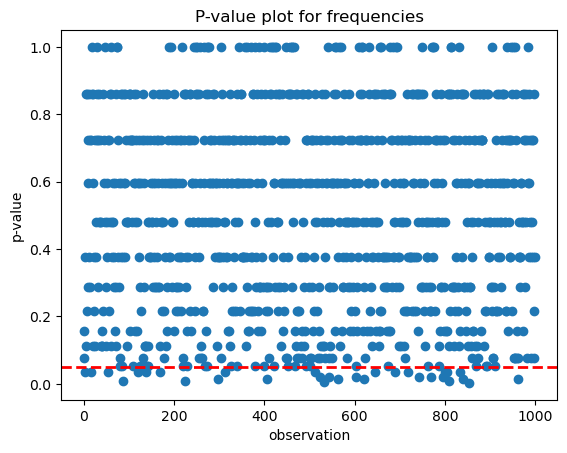

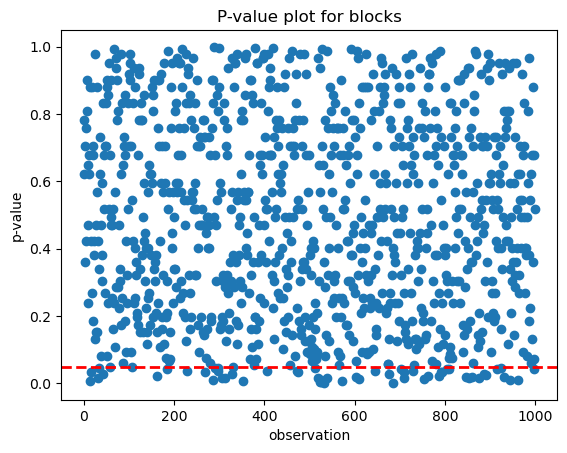

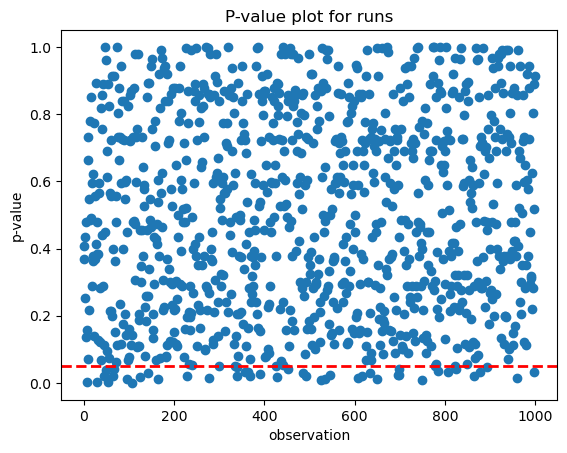

In [159]:
E = [0,7] #represents the elliptic curve y^2 = x^3 + 7
p = 2**256 - 2**32 - 977
x = 0x79BE667EF9DCBBAC55A06295CE870B07029BFCDB2DCE28D959F2815B16F81798
y = 0x483ADA7726A3C4655DA4FBFC0E1108A8FD17B448A68554199C47D08FFB10D4B8
G = [x, y]
n = 128
m = 1000
M = 20
alpha = 0.05

S = generateKSequences(E, p, G, n, m)
data = pVals(S, n, M)

metrics(data, m, alpha)

plotPvals(data, "frequencies", m, alpha)
plotPvals(data, "blocks", m, alpha)
plotPvals(data, "runs", m, alpha)